# Automatic reaction discovery → NeqSim
## From molecular candidates to a reactor and product separation

**A worked integration tutorial · 20 September 2026**

Prepare an [AutomaticReactionDiscovery (ARD)](https://github.com/cgrambow/AutomaticReactionDiscovery)
calculation, import its text output, map molecular identities into NeqSim, and run
a native kinetic reactor followed by cooling and separation.

**Execution boundary:** every displayed process result is calculated with NeqSim.
The bundled ARD-format logs and kinetic parameters are **synthetic teaching fixtures**.
No Gaussian calculation or new reaction discovery was performed for this notebook.
The optional external workflow needs a prepared legacy ARD environment and an available
quantum backend. A successful log is not an experimental validation.

The example follows two competing formic-acid decomposition channels:

$$\mathrm{HCOOH}\rightarrow\mathrm{CO_2}+\mathrm{H_2}$$
$$\mathrm{HCOOH}\rightarrow\mathrm{CO}+\mathrm{H_2O}$$

**You will learn to:**

1. Distinguish a candidate, a checked transition state, and usable kinetics.
2. Reject incomplete logs, unknown species, and unbalanced reaction mappings.
3. Translate a first-order transition-state model into NeqSim `KineticReaction` objects.
4. Connect a `PlugFlowReactor`, `Cooler`, and `Separator` in a reusable `ProcessSystem`.
5. Check rates, conservation, analytical selectivity, mesh sensitivity, and process balances.

The nominal feed is 1 mol/s formic acid and 9 mol/s nitrogen at 650 K and 2 bara.
These conditions and parameters are illustrative, not a recommended production route.

### 1. Runtime and source provenance

Run all cells in a fresh Colab runtime. The Python package is the JPype bridge;
Java calculations use the pinned NeqSim `master` snapshot inspected for this tutorial.
The first run builds a JAR and can take several minutes. Java, Git, and internet access
are required for the Colab build. Restart the runtime if a different JVM was started.

For repeat local validation, `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` may identify
a clean checkout and its built JAR. Commit, hash, and class-location checks still run.
Override `NEQSIM_SOURCE_REF` only when deliberately requalifying a new commit.

In [1]:
import importlib.metadata as metadata
import subprocess
import sys

requirements = {
    "neqsim": "3.20.0", "JPype1": "1.7.1", "numpy": "2.5.3",
    "pandas": "3.0.6", "scipy": "1.18.1", "matplotlib": "3.11.2",
    "rdkit": "2026.3.6",
}
missing = []
for package, required_version in requirements.items():
    try:
        installed_version = metadata.version(package)
    except metadata.PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        missing.append(f"{package}=={required_version}")
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Dependencies ready. Use a fresh runtime to avoid already-imported versions.")

Dependencies ready. Use a fresh runtime to avoid already-imported versions.


In [2]:
import hashlib
import json
import os
from pathlib import Path
import platform
import shutil
import urllib.parse

NEQSIM_SOURCE_REF = os.environ.get(
    "NEQSIM_SOURCE_REF", "1fd6baf4a2e2a09ae8ff9547fff7f77c279d0ec8"
)
ARD_SOURCE_REF = "d44893d4bfdd85411ee326381f48783bb6b3e0ef"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-source")).resolve()
jar_override = os.environ.get("NEQSIM_SOURCE_JAR")

def command_output(arguments, cwd=None):
    return subprocess.check_output(arguments, cwd=cwd, text=True).strip()

if not (source_root / ".git").exists():
    subprocess.run(
        ["git", "clone", "https://github.com/equinor/neqsim.git", str(source_root)],
        check=True,
    )
if not jar_override:
    subprocess.run(["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=source_root, check=True)
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_REF], cwd=source_root, check=True
    )
resolved_commit = command_output(["git", "rev-parse", "HEAD"], source_root)
assert resolved_commit == NEQSIM_SOURCE_REF, "Checkout does not match the pinned commit."
assert not command_output(["git", "diff", "HEAD", "--", "src", "pom.xml"], source_root)
if jar_override:
    source_jar = Path(jar_override).resolve()
else:
    assert shutil.which("java"), "Install Java 17 before building NeqSim."
    subprocess.run(
        ["bash", "mvnw", "-q", "-Dmaven.test.skip=true", "-Dmaven.javadoc.skip=true",
         "-Dcheckstyle.skip", "-Dspotbugs.skip", "-Dpmd.skip=true", "-Djacoco.skip=true",
         "package"],
        cwd=source_root,
        check=True,
    )
    jars = [p for p in (source_root / "target").glob("neqsim-*.jar")
            if not any(word in p.name for word in ("sources", "javadoc", "tests"))]
    assert len(jars) == 1, "Expected exactly one source-built runtime JAR."
    source_jar = jars[0].resolve()
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype

assert not jpype.isJVMStarted(), "Restart the runtime before loading the source JAR."
jpype.addClassPath(str(source_jar))
jpype.startJVM(convertStrings=True)
qualification_class = jpype.JClass(
    "neqsim.process.equipment.reactor.KineticReactionQualification"
)
location = str(qualification_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert Path(urllib.parse.unquote(urllib.parse.urlparse(location).path)).resolve() == source_jar

from neqsim import jneqsim as ns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from scipy.constants import R, Boltzmann, Planck
from scipy.optimize import brentq

pd.set_option("display.max_colwidth", None)

provenance = {
    "neqsim_commit": resolved_commit, "jar_sha256": jar_sha256,
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python": platform.python_version(), "ard_source_commit": ARD_SOURCE_REF,
    "ard_quantum_execution": "NOT RUN; synthetic log fixtures below",
    "dependencies": {name: metadata.version(name) for name in requirements},
}
display(pd.DataFrame(
    [(key, str(value)) for key, value in provenance.items() if key != "dependencies"],
    columns=["Runtime evidence", "Value"],
))
display(pd.DataFrame(provenance["dependencies"].items(), columns=["Package", "Version"]))
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.2,
})
ARTIFACTS = Path("ard_neqsim_outputs")
ARTIFACTS.mkdir(exist_ok=True)

,Runtime evidence,Value
0,neqsim_commit,1fd6baf4a2e2a09ae8ff9547fff7f77c279d0ec8
1,jar_sha256,8c5e337be552f629016ef23f898a1b76968124cab29ebec0a4c910d7aed306d2
2,java,17.0.20
3,python,3.12.14
4,ard_source_commit,d44893d4bfdd85411ee326381f48783bb6b3e0ef
5,ard_quantum_execution,NOT RUN; synthetic log fixtures below


,Package,Version
0,neqsim,3.20.0
1,JPype1,1.7.1
2,numpy,2.5.3
3,pandas,3.0.6
4,scipy,1.18.1
5,matplotlib,3.11.2
6,rdkit,2026.3.6


### 2. Integration contract

| Stage | Owner | Output | Required evidence |
|---|---|---|---|
| Enumerate candidates | ARD `ard.py` | `ARD.log`, job input files | Molecular identity, atom conservation |
| Check a saddle point | ARD `tssearch.py` + quantum backend | Logs, geometries, frequencies, IRC | One imaginary mode, complete IRC, correct endpoints |
| Derive kinetics | Quantum thermochemistry / mechanism specialist | Rate model with units | Thermal corrections, standard states, temperature range |
| Evaluate the reactor | NeqSim | Conversion and axial profiles | Species mapping, single gas phase, numerical checks |
| Cool and separate | NeqSim | Streams and cooler duty | Component, mass and energy closure |

The upstream source is from **2018**. It uses `pybel`, Open Babel, `rmgpy`, an RMG
thermochemistry database, and Python-2-style `iteritems`. Installing the package with
modern Colab `pip` is not a complete ARD installation. Its README documents Gaussian
03/09; the code also contains other backend classes, which are not qualified here.

`ARD.log` contains candidates, not rate constants. In `tssearch.py`, “Barrier height”
and “Reaction energy” are electronic-energy differences converted to kcal/mol.
They are **not** Gibbs activation energies or automatically usable reaction enthalpies.
The parser uses the source's actual log labels, then keeps thermochemical inputs
in a separate, provenance-bearing record.

### 3. Prepare the external discovery job

This cell writes and displays an input file and a launch script. It does not launch a
quantum job. The script is for a **prepared, compatible ARD environment** where the
RMG database and licensed quantum executable have already been checked.

Use a new working directory: upstream ARD deletes/recreates its `reactions` directory.
The command-line options belong after `tssearch.py`; putting `-n` or `-m` before the
script would send them to the Python interpreter.

In [3]:
ard_input = """reac_smi O=CO
nbreak 3
nform 3
dh_cutoff 20
forcefield mmff94
qprog gau
theory m062x/cc-pvtz
"""
(ARTIFACTS / "input.txt").write_text(ard_input)
launch_script = f"""#!/usr/bin/env bash
set -euo pipefail
# Run from a NEW empty working directory in a qualified legacy Python environment.
# Set ARD_ROOT to a checkout at commit {ARD_SOURCE_REF}.
: "${{ARD_ROOT:?Set ARD_ROOT to the prepared ARD checkout}}"
: "${{ARD_PYTHON:?Set ARD_PYTHON to its compatible Python executable}}"
"$ARD_PYTHON" -c 'import pybel, rmgpy; from rmgpy.data.thermo import ThermoDatabase'
"$ARD_PYTHON" "$ARD_ROOT/ard.py" input.txt
for input_file in reactions/[0-9][0-9][0-9][0-9]/input.txt; do
    "$ARD_PYTHON" "$ARD_ROOT/tssearch.py" -n 4 -m 4000 "$input_file"
done
"""
(ARTIFACTS / "run_ard.sh").write_text(launch_script)
print("ARD input:\n" + ard_input)
print("External launch script (generated, NOT executed):\n" + launch_script)

ARD input:
reac_smi O=CO
nbreak 3
nform 3
dh_cutoff 20
forcefield mmff94
qprog gau
theory m062x/cc-pvtz

External launch script (generated, NOT executed):
#!/usr/bin/env bash
set -euo pipefail
# Run from a NEW empty working directory in a qualified legacy Python environment.
# Set ARD_ROOT to a checkout at commit d44893d4bfdd85411ee326381f48783bb6b3e0ef.
: "${ARD_ROOT:?Set ARD_ROOT to the prepared ARD checkout}"
: "${ARD_PYTHON:?Set ARD_PYTHON to its compatible Python executable}"
"$ARD_PYTHON" -c 'import pybel, rmgpy; from rmgpy.data.thermo import ThermoDatabase'
"$ARD_PYTHON" "$ARD_ROOT/ard.py" input.txt
for input_file in reactions/[0-9][0-9][0-9][0-9]/input.txt; do
    "$ARD_PYTHON" "$ARD_ROOT/tssearch.py" -n 4 -m 4000 "$input_file"
done



### 4. Parse ARD results without promoting incomplete jobs

The fixture contains two plausible channel identities. Its numbers and success
messages are authored for testing the adapter; they are not quantum results.
Negative cases demonstrate that an estimated barrier, incomplete run, warning,
or wrong IRC endpoint cannot enter the accepted table.

For real data, `parse_ts_log(path)` accepts an actual `output.####.log`. Inspect the
underlying frequency and IRC files independently: text parsing alone cannot prove
that a transition state or kinetic model is physically correct.

In [4]:
import re

def one_match(pattern, text, field):
    values = re.findall(pattern, text, flags=re.MULTILINE)
    if len(values) != 1:
        raise ValueError(f"Expected one unambiguous {field}; found {len(values)}.")
    return values[0]

def canonical_smiles(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return Chem.MolToSmiles(molecule)

def parse_ts_log(path):
    text = Path(path).read_text()
    if re.search(r"(?im)warning:|error:|unsuccessful|did not run to completion", text):
        raise ValueError("A failure or warning requires manual review.")
    if "Barrier height (estimate)" in text:
        raise ValueError("An estimated barrier is not an accepted TS result.")
    required = [
        "IRC check was successful. The IRC path endpoints correspond to the reactant and product.",
        "Number of gradient evaluations during frequency calculation:",
        "TS search terminated on ",
    ]
    if not all(marker in text for marker in required):
        raise ValueError("Missing frequency, IRC, or normal completion evidence.")
    reactant = canonical_smiles(one_match(r"^Reactant SMILES: (.+)$", text, "reactant"))
    product = canonical_smiles(one_match(r"^Product SMILES: (.+)$", text, "product"))
    endpoint1 = canonical_smiles(one_match(r"^IRC endpoint 1: (.+)$", text, "IRC endpoint 1"))
    endpoint2 = canonical_smiles(one_match(r"^IRC endpoint 2: (.+)$", text, "IRC endpoint 2"))
    if endpoint1 != reactant or endpoint2 != product or reactant == product:
        raise ValueError("IRC endpoints do not match distinct intended structures.")
    number = r"([-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?)"
    barrier = float(one_match(r"^Barrier height = " + number + r" kcal/mol$", text, "barrier"))
    reaction_energy = float(one_match(
        r"^Reaction energy = " + number + r" kcal/mol$", text, "reaction energy"
    ))
    if not np.isfinite([barrier, reaction_energy]).all() or barrier <= 0:
        raise ValueError("Non-finite energy or non-positive barrier requires review.")
    return {
        "channel": Path(path).name.split(".")[1],
        "reactant_smiles": reactant, "product_smiles": product,
        "electronic_barrier_kJ_mol": barrier * 4.184,
        "electronic_reaction_energy_kJ_mol": reaction_energy * 4.184,
        "log_sha256": hashlib.sha256(Path(path).read_bytes()).hexdigest(),
        "evidence": "parsed log only; kinetics not validated",
    }

fixture_root = ARTIFACTS / "synthetic_ard_results"
fixture_root.mkdir(exist_ok=True)
fixtures = [("0000", "O=C=O.[H][H]", 30.0, 7.0), ("0001", "[C-]#[O+].O", 32.0, 10.0)]
for channel, product, barrier, reaction_energy in fixtures:
    fixture_text = f"""# SYNTHETIC TEACHING FIXTURE - NOT AN ARD CALCULATION
Reactant SMILES: O=CO
Product SMILES: {product}
Number of gradient evaluations during frequency calculation: 1
IRC check was successful. The IRC path endpoints correspond to the reactant and product.
IRC endpoint 1: O=CO
IRC endpoint 2: {product}
Barrier height = {barrier:.2f} kcal/mol
Reaction energy = {reaction_energy:.2f} kcal/mol
TS search terminated on SYNTHETIC FIXTURE
"""
    (fixture_root / f"output.{channel}.log").write_text(fixture_text)
def import_ard_directory(results_root):
    paths = sorted(Path(results_root).rglob("output.[0-9][0-9][0-9][0-9].log"))
    if not paths:
        raise ValueError("No ARD transition-state logs found.")
    imported = [parse_ts_log(path) for path in paths]
    identifiers = [row["channel"] for row in imported]
    if len(set(identifiers)) != len(identifiers):
        raise ValueError("Duplicate channel identifiers: import one discovery run at a time.")
    return imported

channels = import_ard_directory(fixture_root)
display(pd.DataFrame(channels)[[
    "channel", "reactant_smiles", "product_smiles", "electronic_barrier_kJ_mol",
    "electronic_reaction_energy_kJ_mol",
]].rename(columns={
    "electronic_barrier_kJ_mol": "Electronic barrier (kJ/mol)",
    "electronic_reaction_energy_kJ_mol": "Electronic reaction energy (kJ/mol)",
}))
print("DATA STATUS: SYNTHETIC. Parser success does not qualify chemical kinetics.")

DATA STATUS: SYNTHETIC. Parser success does not qualify chemical kinetics.


,channel,reactant_smiles,product_smiles,Electronic barrier (kJ/mol),Electronic reaction energy (kJ/mol)
0,0000,O=CO,O=C=O.[H][H],125.520,29.288
1,0001,O=CO,O.[C-]#[O+],133.888,41.840


In [5]:
valid_text = (fixture_root / "output.0000.log").read_text()
negative_cases = {
    "estimated barrier": valid_text.replace("Barrier height =", "Barrier height (estimate) ="),
    "truncated run": valid_text.split("TS search terminated")[0],
    "wrong endpoint": valid_text.replace("IRC endpoint 2: O=C=O.[H][H]", "IRC endpoint 2: O"),
    "partial IRC": valid_text + "\nWARNING: IRC did not run to completion\n",
    "missing frequency": valid_text.replace(
        "Number of gradient evaluations during frequency calculation:", "Unknown field:"
    ),
}
parser_checks = []
for label, content in negative_cases.items():
    rejected_path = fixture_root / "rejected.9999.log"
    rejected_path.write_text(content)
    try:
        parse_ts_log(rejected_path)
    except ValueError:
        parser_checks.append({"Case": label, "Result": "rejected as intended"})
    else:
        raise AssertionError(f"Parser accepted invalid case: {label}")
display(pd.DataFrame(parser_checks))

,Case,Result
0,estimated barrier,rejected as intended
1,truncated run,rejected as intended
2,wrong endpoint,rejected as intended
3,partial IRC,rejected as intended
4,missing frequency,rejected as intended


### 5. Molecular identity → NeqSim components

Canonical SMILES identify a structure; a name lookup alone is insufficient. The explicit
registry is intentionally small. Unknown species, radicals, ions, and isotopologues
are rejected instead of being replaced by similar NeqSim components.
CO's charge-separated SMILES has zero **net** charge and is allowed.

For stoichiometric matrix $N$ (species × reactions) and element matrix $A$
(elements × species), require:

$$AN=0$$

An entry of $A$ is an atom count and an entry of $N$ is a signed molar
stoichiometric coefficient. Negative coefficients consume reactants.

In [6]:
from collections import Counter

species_records = [
    ("O=CO", "formic acid"), ("O=C=O", "CO2"), ("[H][H]", "hydrogen"),
    ("[C-]#[O+]", "CO"), ("O", "water"), ("N#N", "nitrogen"),
]
registry = {canonical_smiles(smiles): name for smiles, name in species_records}
species_names = [name for _, name in species_records]

def mapped_fragments(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        raise ValueError("Invalid SMILES.")
    result = Counter()
    for fragment in Chem.GetMolFrags(molecule, asMols=True):
        if Chem.GetFormalCharge(fragment) != 0:
            raise ValueError("Ionic species require a separately qualified model.")
        if any(atom.GetNumRadicalElectrons() or atom.GetIsotope()
               for atom in fragment.GetAtoms()):
            raise ValueError("Radicals and isotopologues are outside this registry.")
        key = Chem.MolToSmiles(fragment)
        if key not in registry:
            raise ValueError(f"Unmapped molecular structure: {key}")
        result[registry[key]] += 1
    return result

def atom_counts(smiles):
    molecule = Chem.AddHs(Chem.MolFromSmiles(smiles))
    return Counter(atom.GetSymbol() for atom in molecule.GetAtoms())

elements = ["C", "H", "O", "N"]
element_matrix = np.array([
    [atom_counts(smiles)[element] for smiles, _ in species_records]
    for element in elements
], dtype=float)
stoichiometry = np.zeros((len(species_names), len(channels)))
for column, channel in enumerate(channels):
    for side, sign in [("reactant_smiles", -1), ("product_smiles", 1)]:
        for name, count in mapped_fragments(channel[side]).items():
            stoichiometry[species_names.index(name), column] += sign * count
assert np.array_equal(element_matrix @ stoichiometry, np.zeros((4, 2)))
mapping_table = pd.DataFrame([
    {"SMILES": canonical_smiles(smiles), "NeqSim name": name,
     "Formula": rdMolDescriptors.CalcMolFormula(Chem.MolFromSmiles(smiles))}
    for smiles, name in species_records
])
display(mapping_table)
display(pd.DataFrame(stoichiometry, index=species_names, columns=["H2 channel", "CO channel"]))
for invalid_smiles in ["CC(=O)O", "[CH3]", "[Na+]", "[2H][2H]"]:
    try:
        mapped_fragments(invalid_smiles)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Unsupported structure was accepted: {invalid_smiles}")
print("Element balance and unsupported-species rejection checks passed.")

Element balance and unsupported-species rejection checks passed.


,SMILES,NeqSim name,Formula
0,O=CO,formic acid,CH2O2
1,O=C=O,CO2,CO2
2,[H][H],hydrogen,H2
3,[C-]#[O+],CO,CO
4,O,water,H2O
5,N#N,nitrogen,N2


,H2 channel,CO channel
formic acid,-1.0,-1.0
CO2,1.0,0.0
hydrogen,1.0,0.0
CO,0.0,1.0
water,0.0,1.0
nitrogen,0.0,0.0


### 6. Electronic barriers are not kinetic parameters

A quantitative workflow needs thermal corrections, partition functions, a defined
standard state, conformer populations, and possibly tunnelling, pressure falloff,
solvation, or surface kinetics. ARD's electronic barrier does not supply all of these.

For the **illustrative unimolecular** model, use transition-state theory with
transmission coefficient one and constant activation enthalpy/entropy:

$$k(T)=\frac{k_\mathrm{B}T}{h}\exp\left(\frac{\Delta S^\ddagger}{R}-\frac{\Delta H^\ddagger}{RT}\right)$$

$k$ is in s⁻¹, $T$ in K, $k_\mathrm{B}$ in J/K, $h$ in J·s, $R$ in J/(mol·K),
$\Delta H^\ddagger$ in J/mol, and $\Delta S^\ddagger$ in J/(mol·K).
NeqSim's modified Arrhenius form is $k=AT^n\exp(-E_a/RT)$, so set
$n=1$, $A=(k_\mathrm{B}/h)\exp(\Delta S^\ddagger/R)$ in s⁻¹ K⁻¹ and
$E_a=\Delta H^\ddagger$. In an ordinary Arrhenius fit with $n=0$, the apparent
activation energy would include the temperature-prefactor contribution.

For bimolecular reactions, the rate coefficient has different units and needs a
standard-concentration conversion. Do not reuse this mapping unchanged.

In [7]:
thermal_records = pd.DataFrame([
    {"channel": "0000", "dH_activation_J_mol": 125000.0,
     "dS_activation_J_mol_K": -60.0, "dH_reaction_J_mol": 30000.0},
    {"channel": "0001", "dH_activation_J_mol": 135000.0,
     "dS_activation_J_mol_K": -48.0, "dH_reaction_J_mol": 45000.0},
])
thermal_records["evidence"] = "illustrative; not calculated by ARD"
thermal_records["T_min_K"] = 600.0
thermal_records["T_max_K"] = 700.0
thermal_records["log_sha256"] = [row["log_sha256"] for row in channels]
display(thermal_records[[
    "channel", "dH_activation_J_mol", "dS_activation_J_mol_K", "dH_reaction_J_mol"
]])

def tst_rate(temperature, record):
    return (Boltzmann * temperature / Planck) * np.exp(
        record["dS_activation_J_mol_K"] / R
        - record["dH_activation_J_mol"] / (R * temperature)
    )

KineticReaction = ns.process.equipment.reactor.KineticReaction
PlugFlowReactor = ns.process.equipment.reactor.PlugFlowReactor
Stream = ns.process.equipment.stream.Stream
Cooler = ns.process.equipment.heatexchanger.Cooler
Separator = ns.process.equipment.separator.Separator
ProcessSystem = ns.process.processmodel.ProcessSystem

def create_reactions(enthalpy_shift_J_mol=0.0):
    reactions = []
    for column, record in thermal_records.iterrows():
        reaction = KineticReaction("ARD teaching channel " + record["channel"])
        for row, name in enumerate(species_names):
            coefficient = stoichiometry[row, column]
            if coefficient < 0:
                reaction.addReactant(name, float(-coefficient), float(-coefficient))
            elif coefficient > 0:
                reaction.addProduct(name, float(coefficient))
        prefactor = Boltzmann / Planck * np.exp(record["dS_activation_J_mol_K"] / R)
        reaction.setPreExponentialFactor(float(prefactor))
        reaction.setTemperatureExponent(1.0)
        activation_enthalpy = record["dH_activation_J_mol"] + enthalpy_shift_J_mol
        reaction.setActivationEnergy(float(activation_enthalpy))
        reaction.setHeatOfReaction(float(record["dH_reaction_J_mol"]))
        reaction.setRateBasis(KineticReaction.RateBasis.VOLUME)
        reactions.append(reaction)
    return reactions

reactions = create_reactions()
rate_rows = []
for temperature in [600.0, 650.0, 700.0]:
    for index, reaction in enumerate(reactions):
        independent = tst_rate(temperature, thermal_records.iloc[index])
        native = reaction.calculateRateConstant(temperature)
        relative_error = abs(native / independent - 1.0)
        assert relative_error < 2e-5  # NeqSim uses a slightly rounded gas constant.
        rate_rows.append({"T (K)": temperature, "Channel": index,
                          "TST k (1/s)": independent, "NeqSim k (1/s)": native,
                          "Relative difference": relative_error})
display(pd.DataFrame(rate_rows).round(7))

,channel,dH_activation_J_mol,dS_activation_J_mol_K,dH_reaction_J_mol
0,0000,125000.0,-60.0,30000.0
1,0001,135000.0,-48.0,45000.0


,T (K),Channel,TST k (1/s),NeqSim k (1/s),Relative difference
0,600.0,0,0.120492,0.120491,0.000008
1,600.0,1,0.068738,0.068738,0.000008
2,650.0,0,0.897008,0.897002,0.000007
3,650.0,1,0.597043,0.597039,0.000008
4,700.0,0,5.040527,5.040493,0.000007
5,700.0,1,3.828995,3.828967,0.000007


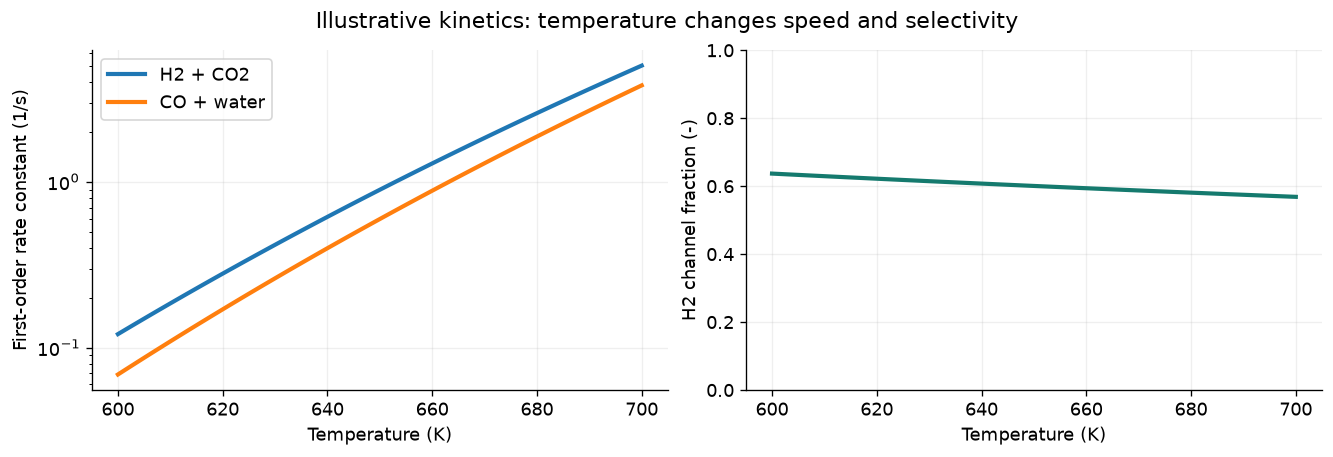

In [8]:
temperature_grid = np.linspace(600.0, 700.0, 80)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), layout="constrained")
rate_grid = np.array([
    [reaction.calculateRateConstant(float(temperature)) for temperature in temperature_grid]
    for reaction in reactions
])
for index, label in enumerate(["H2 + CO2", "CO + water"]):
    axes[0].semilogy(temperature_grid, rate_grid[index], label=label, linewidth=2.5)
axes[0].set(xlabel="Temperature (K)", ylabel="First-order rate constant (1/s)")
axes[0].legend()
axes[1].plot(temperature_grid, rate_grid[0] / rate_grid.sum(axis=0), color="#157a6e", lw=2.5)
axes[1].set(xlabel="Temperature (K)", ylabel="H2 channel fraction (-)", ylim=(0, 1))
fig.suptitle("Illustrative kinetics: temperature changes speed and selectivity", fontsize=13)
plt.show()

Both channel rates increase with temperature. Their relative activation parameters
also change the product split. This is why ranking electronic barriers alone is
insufficient: entropy and operating temperature affect which channel matters.
These curves demonstrate the parameter handoff; they are not formic-acid rate data.

### 7. A native NeqSim reactor and separation train

Use Peng–Robinson with the classic mixing rule. `FULLY_COUPLED` refreshes the
thermodynamic state inside the reactor's numerical residual evaluations. The reactor
is isothermal, with no catalyst model; both reactions are irreversible, homogeneous,
and first-order in gas-phase formic acid. NeqSim evaluates concentrations in mol/m³
and rates in mol/(m³·s).

$$\frac{dF_i}{dz}=A_c\sum_j\nu_{ij}r_j$$

$F_i$ is species molar flow (mol/s), $z$ axial position (m), $A_c$ total tube
cross-sectional area (m²), $\nu_{ij}$ a stoichiometric coefficient, and $r_j$ a
volumetric reaction rate. Conversion changes total molar flow and volumetric flow.

The reactor is 2 m long and 0.30 m in diameter. Its outlet is cooled to 303.15 K
at essentially 2 bara and separated. Peng–Robinson is a teaching property model:
acid association/dimerization and quantitative acid–water VLE need dedicated
qualification. Do not interpret the condensate split as validated plant performance.

In [9]:
feed_vector = np.array([1.0, 0.0, 0.0, 0.0, 0.0, 9.0])

def stream_flows(stream):
    fluid = stream.getFluid()
    return np.array([
        float(fluid.getComponent(name).getNumberOfmoles()) if fluid.hasComponent(name) else 0.0
        for name in species_names
    ])

def build_case(temperature_K=650.0, pressure_bara=2.0, steps=80, enthalpy_shift=0.0):
    assert 600.0 <= temperature_K <= 700.0
    fluid = ns.thermo.system.SystemPrEos(float(temperature_K), float(pressure_bara))
    for name, molar_flow in zip(species_names, feed_vector):
        fluid.addComponent(name, float(molar_flow))
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    feed = Stream("Formic acid and nitrogen feed", fluid)
    feed.run()
    assert feed.getFluid().getNumberOfPhases() == 1
    assert str(feed.getFluid().getPhase(0).getPhaseTypeName()) == "gas"
    reactor = PlugFlowReactor("Reaction discovery demonstrator", feed)
    reactor.setLength(2.0, "m")
    reactor.setDiameter(0.30, "m")
    reactor.setNumberOfSteps(int(steps))
    reactor.setIntegrationMethod("RK4")
    reactor.setEnergyMode(PlugFlowReactor.EnergyMode.ISOTHERMAL)
    reactor.setThermodynamicCoupling(PlugFlowReactor.ThermodynamicCoupling.FULLY_COUPLED)
    reactor.setKeyComponent("formic acid")
    for reaction in create_reactions(enthalpy_shift):
        reactor.addReaction(reaction)
    cooler = Cooler("Product cooler", reactor.getOutletStream())
    cooler.setOutTemperature(303.15)
    separator = Separator("Product separator", cooler.getOutletStream())
    process = ProcessSystem()
    for unit in [feed, reactor, cooler, separator]:
        process.add(unit)
    process.run()
    outlet = reactor.getOutletStream()
    assert outlet.getFluid().getNumberOfPhases() == 1
    return {"process": process, "feed": feed, "reactor": reactor,
            "reactor_outlet": outlet, "cooler": cooler, "separator": separator,
            "gas": separator.getGasOutStream(), "liquid": separator.getLiquidOutStream()}

base_case = build_case()
stream_table = pd.DataFrame({
    "Feed (mol/s)": stream_flows(base_case["feed"]),
    "Reactor outlet (mol/s)": stream_flows(base_case["reactor_outlet"]),
    "Separated gas (mol/s)": stream_flows(base_case["gas"]),
    "Separated liquid (mol/s)": stream_flows(base_case["liquid"]),
}, index=species_names)
display(stream_table.round(6))
print("Native process units:", base_case["process"].getUnitOperations().size())
print("Reactor conversion:", round(base_case["reactor"].getConversion(), 6))
print("Cooler duty, negative = cooling (kW):", round(base_case["cooler"].getDuty() / 1000, 3))

Native process units: 4
Reactor conversion: 0.5316
Cooler duty, negative = cooling (kW): -126.113


,Feed (mol/s),Reactor outlet (mol/s),Separated gas (mol/s),Separated liquid (mol/s)
formic acid,1.0,0.468400,0.265496,0.202904
CO2,0.0,0.319165,0.318964,0.000201
hydrogen,0.0,0.319165,0.319162,0.000003
CO,0.0,0.212434,0.212431,0.000003
water,0.0,0.212434,0.188165,0.024269
nitrogen,9.0,9.000000,8.999848,0.000152


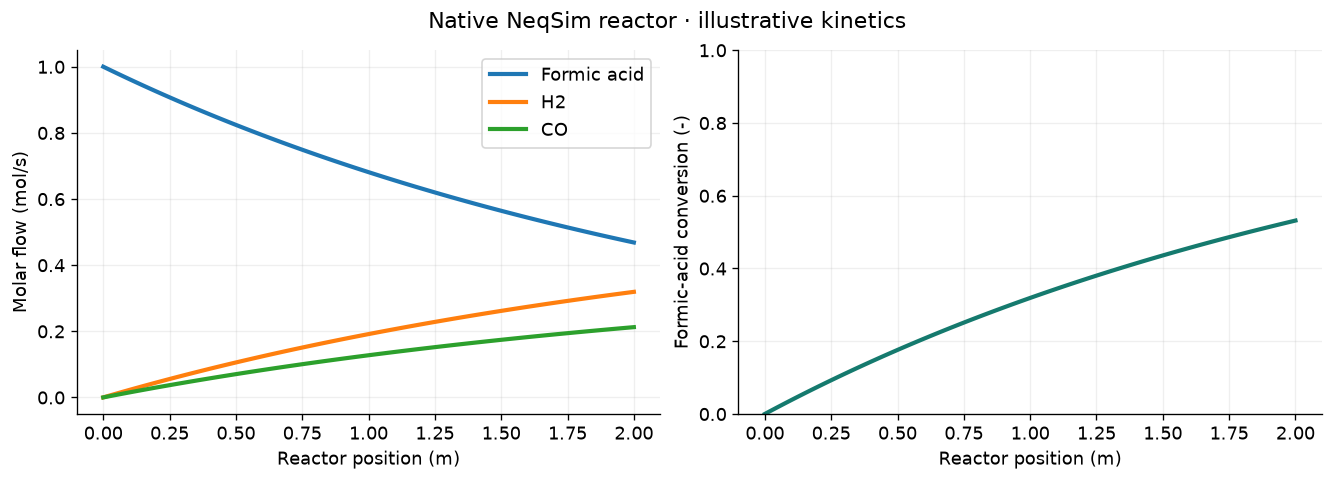

In [10]:
profile = base_case["reactor"].getAxialProfile()
position = np.array(profile.getPositionProfile())
profile_names = [str(name) for name in profile.getComponentNames()]
profile_flows = np.array(profile.getMolarFlowProfiles())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained")
for name, label in [("formic acid", "Formic acid"), ("hydrogen", "H2"), ("CO", "CO")]:
    axes[0].plot(position, profile_flows[:, profile_names.index(name)], label=label, lw=2.5)
axes[0].set(xlabel="Reactor position (m)", ylabel="Molar flow (mol/s)")
axes[0].legend()
axes[1].plot(position, np.array(profile.getConversionProfile()), color="#157a6e", lw=2.5)
axes[1].set(xlabel="Reactor position (m)", ylabel="Formic-acid conversion (-)", ylim=(0, 1))
fig.suptitle("Native NeqSim reactor · illustrative kinetics", fontsize=13)
plt.show()

The formic-acid flow decreases while both product-channel flows increase. Their
constant ratio along this isothermal reactor follows from two first-order rates
sharing the same reactant concentration. Nitrogen remains inert. The native stream
objects in `base_case` can be connected to additional NeqSim equipment.

### 8. Independent checks and numerical convergence

For this two-channel first-order model, the exact isothermal channel fraction is:

$$S_{\mathrm{H_2}}=\frac{k_1}{k_1+k_2}$$

An additional low-pressure check accounts for ideal-gas expansion in a constant-pressure
PFR. With conversion $X$, feed mole fraction $y_{A0}=0.1$, total rate constant $k$,
and inlet ideal volume flow $q_0=F_{T0}RT/P$:

$$-(1+y_{A0})\ln(1-X)-y_{A0}X=\frac{kV}{q_0}$$

$V$ is reactor volume (m³), $P$ is absolute pressure (Pa), and $F_{T0}$ is total feed
molar flow (mol/s). This benchmark neglects the small pressure drop and real-gas effects;
therefore the NeqSim result need not match it exactly.

In [11]:
outlet_vector = stream_flows(base_case["reactor_outlet"])
reactor_element_error = element_matrix @ (outlet_vector - feed_vector)
separator_error = (
    stream_flows(base_case["gas"]) + stream_flows(base_case["liquid"]) - outlet_vector
)
molecular_weights = np.array([
    base_case["feed"].getFluid().getComponent(name).getMolarMass() for name in species_names
])
relative_mass_error = abs((outlet_vector - feed_vector) @ molecular_weights) / (
    feed_vector @ molecular_weights
)
measured_selectivity = outlet_vector[2] / (outlet_vector[2] + outlet_vector[3])
rate_constants = np.array([reaction.calculateRateConstant(650.0) for reaction in reactions])
exact_selectivity = rate_constants[0] / rate_constants.sum()
volume = np.pi * 0.30**2 / 4 * 2.0
ideal_flow = feed_vector.sum() * R * 650.0 / 2e5
damkohler = rate_constants.sum() * volume / ideal_flow
ideal_conversion = brentq(
    lambda conversion: -1.1 * np.log1p(-conversion) - 0.1 * conversion - damkohler,
    0.0, 1.0 - 1e-12,
)
enthalpy_in = base_case["reactor_outlet"].getFluid().getEnthalpy()
enthalpy_out = base_case["cooler"].getOutletStream().getFluid().getEnthalpy()
cooler_energy_error = abs(enthalpy_out - enthalpy_in - base_case["cooler"].getDuty())
checks = {
    "Reactor element residual (mol atoms/s)": (np.max(np.abs(reactor_element_error)), 1e-8),
    "Separator component residual (mol/s)": (np.max(np.abs(separator_error)), 1e-8),
    "Relative mass residual (-)": (relative_mass_error, 2e-5),
    "Absolute channel-selectivity error (-)": (abs(measured_selectivity - exact_selectivity), 1e-8),
    "PR versus ideal conversion difference (-)": (
        abs(base_case["reactor"].getConversion() - ideal_conversion), 0.015
    ),
    "Cooler energy residual (W)": (cooler_energy_error, 1e-6),
}
gas_phase = base_case["feed"].getFluid().getPhase(0)
concentration = gas_phase.getComponent("formic acid").getx() * gas_phase.getDensity("mol/m3")
rate_error = max(
    abs(reaction.calculateRate(base_case["feed"].getFluid(), 0)
        / (reaction.calculateRateConstant(650.0) * concentration) - 1.0)
    for reaction in reactions
)
checks["Native concentration-rate error (-)"] = (rate_error, 1e-12)
profile_in_registry_order = profile_flows[:, [profile_names.index(n) for n in species_names]]
axial_element_error = profile_in_registry_order @ element_matrix.T - feed_vector @ element_matrix.T
checks["Axial element residual (mol atoms/s)"] = (np.max(np.abs(axial_element_error)), 1e-8)
assert np.all(profile_flows >= -1e-12)
for label, (value, limit) in checks.items():
    assert np.isfinite(value) and value <= limit, (label, value, limit)
display(pd.DataFrame([
    {"Check": label, "Residual": value, "Tolerance": limit, "Result": "PASS"}
    for label, (value, limit) in checks.items()
]))
print(f"Independent ideal-gas conversion: {ideal_conversion:.6f}")
print(f"NeqSim PR conversion: {base_case['reactor'].getConversion():.6f}")
print("Mass tolerance allows small inconsistencies in database molecular-weight rounding.")

Independent ideal-gas conversion: 0.531833
NeqSim PR conversion: 0.531600
Mass tolerance allows small inconsistencies in database molecular-weight rounding.


,Check,Residual,Tolerance,Result
0,Reactor element residual (mol atoms/s),8.881784e-16,1.000000e-08,PASS
1,Separator component residual (mol/s),3.907985e-14,1.000000e-08,PASS
2,Relative mass residual (-),1.105468e-06,2.000000e-05,PASS
3,Absolute channel-selectivity error (-),1.110223e-16,1.000000e-08,PASS
4,PR versus ideal conversion difference (-),2.334997e-04,1.500000e-02,PASS
5,Cooler energy residual (W),0.000000e+00,1.000000e-06,PASS
6,Native concentration-rate error (-),0.000000e+00,1.000000e-12,PASS
7,Axial element residual (mol atoms/s),8.881784e-16,1.000000e-08,PASS


In [12]:
mesh_rows = []
for steps in [20, 40, 80, 160]:
    mesh_case = base_case if steps == 80 else build_case(steps=steps)
    mesh_rows.append({"Axial steps": steps,
                      "Conversion": mesh_case["reactor"].getConversion(),
                      "H2 (mol/s)": stream_flows(mesh_case["reactor_outlet"])[2]})
mesh_table = pd.DataFrame(mesh_rows)
mesh_difference = abs(mesh_table.iloc[-1]["Conversion"] - mesh_table.iloc[-2]["Conversion"])
assert mesh_difference < 1e-6
display(mesh_table.round(10))
print(f"80-to-160-step conversion difference: {mesh_difference:.3e}")

80-to-160-step conversion difference: 2.334e-11


,Axial steps,Conversion,H2 (mol/s)
0,20,0.5316,0.319165
1,40,0.5316,0.319165
2,80,0.5316,0.319165
3,160,0.5316,0.319165


### 9. Diagnose a native heat-duty limitation

The current `PlugFlowReactor.getHeatDuty()` assigns the entire loss of a shared
reactant to each parallel reaction. That double-counts channel extents. This is tracked
in [NeqSim issue #3859](https://github.com/equinor/neqsim/issues/3859).

For this network, independent channel extents can be reconstructed from CO₂ and CO
production. The table compares both calculations using the native
minus-reaction-enthalpy sign convention. **The native reactor duty is excluded from
the qualified outputs of this tutorial.** The extent sum is only a bookkeeping check
using illustrative constant reaction enthalpies; it is not a complete reactor energy
balance or a heater design. The downstream cooler preserves composition and its
energy balance is checked separately above.

In [13]:
channel_extents = outlet_vector[[1, 3]]
extent_based_heat = -float(channel_extents @ thermal_records["dH_reaction_J_mol"].to_numpy())
native_heat = float(base_case["reactor"].getHeatDuty())
display(pd.DataFrame([
    {"Quantity": "Native reactor duty — known issue #3859", "Value (kW)": native_heat / 1000},
    {"Quantity": "Independent channel-extent sum", "Value (kW)": extent_based_heat / 1000},
    {"Quantity": "Difference — excluded from accepted outputs",
     "Value (kW)": (native_heat - extent_based_heat) / 1000},
]))
print("Reaction-enthalpy bookkeeping is diagnostic; no reactor thermal design is claimed.")

Reaction-enthalpy bookkeeping is diagnostic; no reactor thermal design is claimed.


,Quantity,Value (kW)
0,Native reactor duty — known issue #3859,-39.869986
1,Independent channel-extent sum,-19.134511
2,Difference — excluded from accepted outputs,-20.735476


### 10. Temperature, uncertainty, and downstream consequences

Run the complete native process at each temperature. The shaded conversion interval
comes from shifting **both** illustrative activation enthalpies by ±5 kJ/mol; it is a
deterministic sensitivity band, not a statistical confidence interval. The channel
fraction is unchanged by an equal shift, while conversion and gas production change.

,T (K),Conversion,H2 (mol/s),CO (mol/s),Cooling removed (kW),Liquid (mol/s)
1,600.0,0.1012,0.0644,0.0367,124.8278,0.6425
4,625.0,0.2569,0.1587,0.0981,127.9523,0.4972
7,650.0,0.5316,0.3192,0.2124,126.1125,0.2275
10,675.0,0.8340,0.4869,0.3471,132.6156,0.1501
13,700.0,0.9817,0.5579,0.4238,144.5297,0.2256


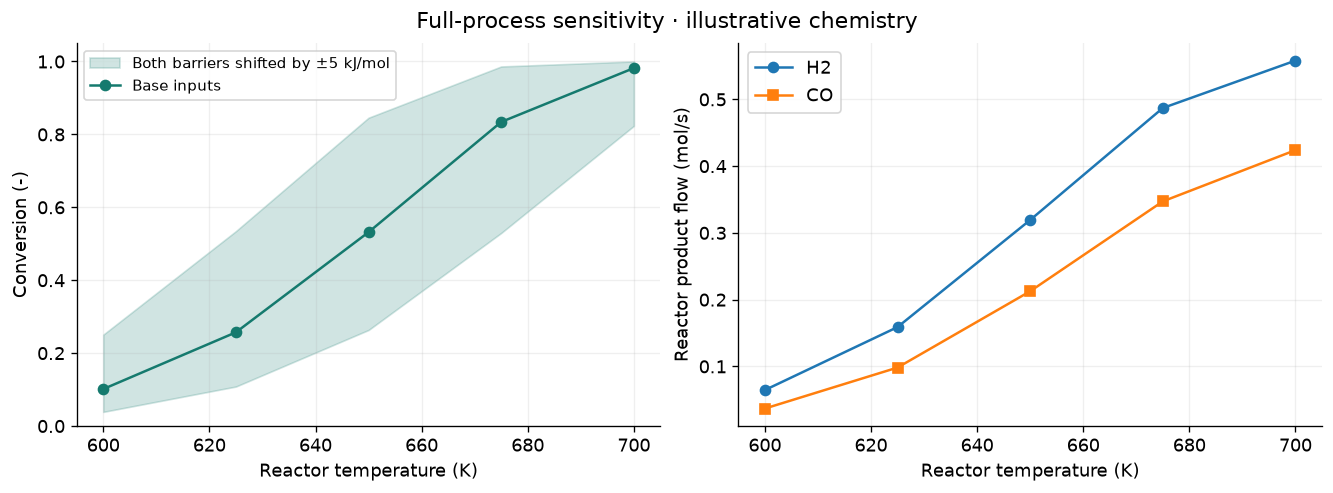

In [14]:
sensitivity_rows = []
for temperature in [600.0, 625.0, 650.0, 675.0, 700.0]:
    for shift in [-5000.0, 0.0, 5000.0]:
        case = build_case(temperature_K=temperature, steps=60, enthalpy_shift=shift)
        flows = stream_flows(case["reactor_outlet"])
        sensitivity_rows.append({
            "T (K)": temperature, "Barrier shift (kJ/mol)": shift / 1000,
            "Conversion": case["reactor"].getConversion(),
            "H2 (mol/s)": flows[2], "CO (mol/s)": flows[3],
            "Cooling removed (kW)": -case["cooler"].getDuty() / 1000,
            "Liquid (mol/s)": stream_flows(case["liquid"]).sum(),
        })
sensitivity = pd.DataFrame(sensitivity_rows)
central = sensitivity[sensitivity["Barrier shift (kJ/mol)"] == 0]
display(central.drop(columns="Barrier shift (kJ/mol)").round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
envelope = sensitivity.groupby("T (K)")["Conversion"].agg(["min", "max"])
axes[0].fill_between(envelope.index, envelope["min"], envelope["max"], alpha=0.20,
                     color="#157a6e", label="Both barriers shifted by ±5 kJ/mol")
axes[0].plot(central["T (K)"], central["Conversion"], "o-", color="#157a6e", label="Base inputs")
axes[0].set(xlabel="Reactor temperature (K)", ylabel="Conversion (-)", ylim=(0, 1.05))
axes[0].legend(fontsize=9)
axes[1].plot(central["T (K)"], central["H2 (mol/s)"], "o-", label="H2")
axes[1].plot(central["T (K)"], central["CO (mol/s)"], "s-", label="CO")
axes[1].set(xlabel="Reactor temperature (K)", ylabel="Reactor product flow (mol/s)")
axes[1].legend()
fig.suptitle("Full-process sensitivity · illustrative chemistry", fontsize=13)
plt.show()

The sensitivity band shows why a usable discovery-to-process workflow must carry
kinetic uncertainty. A few kJ/mol can materially change conversion over a fixed
reactor volume. Higher conversion does not by itself ensure a useful hydrogen stream:
CO co-production and nitrogen dilution remain visible in the stream table.
An engineering study would qualify kinetics, selectivity, and separation properties
before optimizing reactor size or downstream purification.

### 11. Export a reviewable handoff and attach real ARD results

The JSON export keeps structures, stoichiometry, log hashes, source versions, units,
temperature bounds, and evidence labels together. CSV files preserve numerical
outputs. Native objects remain available as `base_case["process"]`,
`base_case["reactor_outlet"]`, `base_case["gas"]`, and `base_case["liquid"]`.

To replace the fixture:

1. Run the generated input in a prepared ARD environment and retain the entire job directory.
2. Call `import_ard_directory` on the actual job folder. It recursively imports
   `output.####.log` files and refuses incomplete jobs or duplicate channel IDs.
3. Independently review frequencies, complete IRC paths, connectivity, multiplicity,
   and conformers. Logs with warnings require manual review.
4. Calculate temperature-dependent thermochemistry and rates with explicit standard states.
   Replace `thermal_records` with a reviewed model. Do not insert electronic
   barriers directly or reuse the fixture's entropy/enthalpy values.
5. Extend the registry only after checking EOS parameters and binary interactions.
   Rebuild stoichiometry and rerun the conservation tests.
6. Qualify the mechanism against independent data before process predictions.

This downstream example is specific to the two stated channels. A different network
requires updating stoichiometry, kinetics, feed, and analytical checks; it must not
silently run with the original fixture parameters.

In [15]:
qualification = qualification_class(
    "ARD illustrative channels", "Synthetic inputs; no quantum calculation",
    "https://github.com/cgrambow/AutomaticReactionDiscovery",
    ns.chemicalreactions.chemicalreaction.ChemicalReactionValidationStatus.UNVALIDATED,
    600.0, 700.0, 1.0, 3.0,
    "Teaching integration only; electronic barriers are not validated rate constants.",
)
try:
    qualification.requireValidatedAt(650.0, 2.0)
except jpype.JException as error:
    print("Expected qualification rejection:", str(error).split(":", 1)[-1].strip())
else:
    raise AssertionError("Illustrative kinetics must not be labelled independently validated.")
handoff = {
    "schema_version": 1, "artifact_kind": "synthetic_teaching_example",
    "provenance": provenance,
    "species": mapping_table.to_dict(orient="records"),
    "stoichiometry_species_by_reaction": stoichiometry.tolist(),
    "channels": channels, "thermal_model": thermal_records.to_dict(orient="records"),
    "rate_basis": "homogeneous gas; mol/(m3*s); first-order k in 1/s",
    "independently_validated": False,
    "known_issues": ["https://github.com/equinor/neqsim/issues/3859"],
}
(ARTIFACTS / "reaction_handoff.json").write_text(json.dumps(handoff, indent=2))
stream_table.to_csv(ARTIFACTS / "stream_results.csv")
sensitivity.to_csv(ARTIFACTS / "sensitivity.csv", index=False)
mesh_table.to_csv(ARTIFACTS / "mesh_convergence.csv", index=False)
display(pd.DataFrame([
    {"File": path.name, "Bytes": path.stat().st_size}
    for path in sorted(ARTIFACTS.iterdir()) if path.is_file()
]))

Expected qualification rejection: Kinetic reaction 'ARD illustrative channels' is not independently validated: UNVALIDATED


,File,Bytes
0,input.txt,93
1,mesh_convergence.csv,200
2,reaction_handoff.json,3094
3,run_ard.sh,596
4,sensitivity.csv,1699
5,stream_results.csv,494


In [16]:
display(Markdown(
    f"**Calculated teaching result:** at 650 K and 2 bara, conversion is "
    f"{100 * base_case['reactor'].getConversion():.2f}%, with "
    f"{outlet_vector[2]:.4f} mol/s H₂ and {outlet_vector[3]:.4f} mol/s CO. "
    f"The product cooler removes {-base_case['cooler'].getDuty() / 1000:.2f} kW. "
    f"Element, separator-component, mass, selectivity, and cooler-energy checks pass; "
    f"the 80-to-160-step conversion difference is {mesh_difference:.2e}. "
    "These results validate the adapter and numerical workflow, not the illustrative chemistry."
))

**Calculated teaching result:** at 650 K and 2 bara, conversion is 53.16%, with 0.3192 mol/s H₂ and 0.2124 mol/s CO. The product cooler removes 126.11 kW. Element, separator-component, mass, selectivity, and cooler-energy checks pass; the 80-to-160-step conversion difference is 2.33e-11. These results validate the adapter and numerical workflow, not the illustrative chemistry.

### 12. Scope, exercises, and source references

**Demonstrated:** ARD input generation; source-matched log parsing and rejection tests;
molecular mapping; element closure; explicit synthetic TST-to-Arrhenius conversion;
native NeqSim process integration; analytical and mesh checks; uncertainty sensitivity;
retained outputs and JSON/CSV handoffs.

**Not demonstrated:** a live ARD/Gaussian calculation, new discoveries, experimentally
validated rates, reversible detailed balance, pressure-dependent kinetics, surface
catalysis, liquid-phase reactions, acid association, or reactor thermal design.
The ±5 kJ/mol study is a scenario range, not an inferred distribution.

**Known NeqSim limitation:** [#3859: parallel-reaction isothermal duty](https://github.com/equinor/neqsim/issues/3859).
The reported conversion, species flows, and composition-preserving cooler calculations
do not use the defective reactor-duty value. No native reaction-discovery importer
is assumed: the explicit adapter is part of this notebook.

**Exercises:** increase reactor length and recheck mesh convergence; vary activation
entropies independently and inspect selectivity; investigate an association model for
the cold separator; replace fixtures with reviewed quantum results and kinetic measurements.

**Primary sources inspected:**

- [ARD README and workflow](https://github.com/cgrambow/AutomaticReactionDiscovery/blob/d44893d4bfdd85411ee326381f48783bb6b3e0ef/README.md).
- [Candidate generation and input parsing](https://github.com/cgrambow/AutomaticReactionDiscovery/blob/d44893d4bfdd85411ee326381f48783bb6b3e0ef/ard/main.py).
- [Transition-state, frequency, IRC and energy-output logic](https://github.com/cgrambow/AutomaticReactionDiscovery/blob/d44893d4bfdd85411ee326381f48783bb6b3e0ef/tssearch.py).
- [ARD dependencies](https://github.com/cgrambow/AutomaticReactionDiscovery/blob/d44893d4bfdd85411ee326381f48783bb6b3e0ef/requirements.txt)
  and [MIT license](https://github.com/cgrambow/AutomaticReactionDiscovery/blob/d44893d4bfdd85411ee326381f48783bb6b3e0ef/LICENSE).
- [NeqSim KineticReaction](https://github.com/equinor/neqsim/blob/1fd6baf4a2e2a09ae8ff9547fff7f77c279d0ec8/src/main/java/neqsim/process/equipment/reactor/KineticReaction.java).
- [NeqSim PlugFlowReactor](https://github.com/equinor/neqsim/blob/1fd6baf4a2e2a09ae8ff9547fff7f77c279d0ec8/src/main/java/neqsim/process/equipment/reactor/PlugFlowReactor.java).
- [Kinetic qualification metadata](https://github.com/equinor/neqsim/blob/1fd6baf4a2e2a09ae8ff9547fff7f77c279d0ec8/src/main/java/neqsim/process/equipment/reactor/KineticReactionQualification.java).

ARD credits Colin Grambow and William H. Green in its package metadata.
No upstream implementation or measured dataset is redistributed. The log fixtures
are original synthetic examples matching the inspected output grammar.